In [1]:
!pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import requests

In [3]:
df = pd.read_csv("/root/code/hackathon/virtual-bank-agentic-consultant/correct_trading_data.csv")
df

,transaction_id,customer_id,datetime,stock_code,action,quantity,price,fee
0,TC00001_0_BUY_0,C00001,2024-07-03 11:24:00,PVD,buy,15,29.34,1.202270
1,TC00001_0_BUY_1,C00001,2024-07-03 14:07:00,SHB,buy,79,7.93,2.735075
2,TC00001_0_BUY_2,C00001,2024-07-03 13:22:00,SHB,buy,83,8.65,1.811411
3,TC00001_0_BUY_3,C00001,2024-07-03 11:25:00,PET,buy,77,30.18,9.235374
4,TC00001_0_BUY_4,C00001,2024-07-03 10:42:00,VHC,buy,14,68.23,2.807521
...,...,...,...,...,...,...,...,...
439641,TC01000_48_BUY_2,C01000,2025-09-30 13:11:00,PVS,buy,37,29.72,2.060354
439642,TC01000_48_BUY_3,C01000,2025-09-30 10:00:00,GMD,buy,37,67.90,4.572471
439643,TC01000_48_BUY_4,C01000,2025-09-30 10:22:00,LPB,buy,50,49.50,8.586915
439644,TC01000_49_SELL_0,C01000,2025-10-07 09:35:00,PDR,sell,8,22.75,0.578334


In [4]:
with open("/root/code/hackathon/virtual-bank-agentic-consultant/backend/app/data/company/summary.json", "r", encoding="utf-8") as f:
    company_data = json.load(f)

def match_sector(symbol):
    return company_data[symbol]["sector"]
df["sector"] = df["stock_code"].apply(match_sector)
df["sector"].value_counts()

sector
Real Estate               87011
Banking                   83219
Basic Materials           59434
Industrials               50720
Consumer Staples          43206
Financial Services        31058
Energy                    20946
Retail                    14770
Technology                10502
Conglomerates             10195
Utilities                  9104
Consumer Discretionary     8957
Insurance                  5879
Communication Services     4645
Name: count, dtype: int64

In [5]:
with open("/root/code/hackathon/virtual-bank-agentic-consultant/backend/app/data/customer/behaviour_labels.json", "r", encoding="utf-8") as f:
    trading_styles = json.load(f)

trading_style_df = pd.DataFrame()
trading_style_df["customer_id"] = trading_styles.keys()
trading_style_df["style"] = trading_styles.values()
trading_style_df

,customer_id,style
0,C00001,short_term
1,C00002,short_term
2,C00003,swing
3,C00004,swing
4,C00005,swing
...,...,...
995,C00996,swing
996,C00997,long_term
997,C00998,short_term
998,C00999,swing


In [6]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['total_value'] = df['quantity'] * df['price']

In [7]:
customer_df = df.groupby('customer_id').agg(
    total_trades=('transaction_id', 'count'),
    total_volume=('quantity', 'sum'),
    total_invested=('total_value', 'sum'),
    total_fees=('fee', 'sum'),
    unique_stocks=('stock_code', 'nunique'),
    first_transaction=('datetime', 'min'),
    last_transaction=('datetime', 'max')
).reset_index()

customer_df["active_days"] = (
    (customer_df["last_transaction"] - customer_df["first_transaction"])
    .dt.days + 1
)

customer_df["trading_frequency"] = (
    customer_df["total_trades"] / customer_df["active_days"]
)

customer_df["total_invested_frequency"] = (
    customer_df["total_invested"] / customer_df["active_days"]
)

customer_df["total_volume_frequency"] = (
    customer_df["total_volume"] / customer_df["active_days"]
)


customer_df["total_fees_frequency"] = (
    customer_df["total_fees"] / customer_df["active_days"]
)

customer_df["unique_stocks_frequency"] = (
    customer_df["unique_stocks"] / customer_df["active_days"]
)


customer_df


,customer_id,total_trades,total_volume,total_invested,total_fees,unique_stocks,first_transaction,last_transaction,active_days,trading_frequency,total_invested_frequency,total_volume_frequency,total_fees_frequency,unique_stocks_frequency
0,C00001,961,75079,2150562.73,6457.673859,11,2024-07-03 10:31:00,2025-10-07 14:40:00,462,2.080087,4654.897684,162.508658,13.977649,0.023810
1,C00002,1038,83639,1765136.82,5449.519672,6,2024-07-03 09:47:00,2025-10-06 13:30:00,461,2.251627,3828.930195,181.429501,11.821084,0.013015
2,C00003,193,14282,549384.47,1546.373027,11,2024-07-03 09:19:00,2025-10-03 14:41:00,458,0.421397,1199.529410,31.183406,3.376360,0.024017
3,C00004,152,9805,573716.87,1681.607748,13,2024-07-03 09:05:00,2026-03-20 14:44:00,626,0.242812,916.480623,15.662939,2.686274,0.020767
4,C00005,177,13349,370855.25,1105.123220,11,2024-07-03 13:00:00,2025-10-06 14:21:00,461,0.383948,804.458243,28.956616,2.397230,0.023861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,C00996,165,11044,423141.40,1316.567883,12,2024-07-03 10:07:00,2025-10-02 14:31:00,457,0.361050,925.911160,24.166302,2.880893,0.026258
996,C00997,15,892,27584.59,89.629812,4,2024-07-18 10:41:00,2025-10-06 14:13:00,446,0.033632,61.848857,2.000000,0.200964,0.008969
997,C00998,951,72945,2211481.34,6449.281336,15,2024-07-03 09:10:00,2025-10-08 14:11:00,463,2.053996,4776.417581,157.548596,13.929333,0.032397
998,C00999,158,10447,326857.50,924.633564,10,2024-07-03 13:12:00,2025-10-02 14:03:00,457,0.345733,715.224289,22.859956,2.023268,0.021882


In [8]:
current_date = df['datetime'].max()
customer_df['recency'] = (current_date - customer_df['last_transaction']).dt.days

customer_df["active_days_recency"] = (
    customer_df["recency"] / customer_df["active_days"]
)

In [9]:
action_counts = df.pivot_table(index='customer_id', columns='action', values='transaction_id', aggfunc='count', fill_value=0)
customer_df['buy_ratio'] = list(action_counts['buy'] / (action_counts['buy'] + action_counts['sell']))
customer_df['buy_ratio'] = customer_df['buy_ratio'].fillna(0.5)
customer_df['buy_ratio']

0      0.608741
1      0.633911
2      0.606218
3      0.559211
4      0.615819
         ...   
995    0.587879
996    0.866667
997    0.598318
998    0.670886
999    0.550562
Name: buy_ratio, Length: 1000, dtype: float64

In [10]:
sector_pivot = df.pivot_table(index='customer_id', columns='sector', values='total_value', aggfunc='sum', fill_value=0)
sector_pct = sector_pivot.div(sector_pivot.sum(axis=1), axis=0)
sector_pct.columns = [f'pct_{col}' for col in sector_pct.columns]

final_df = pd.merge(customer_df, sector_pct, on='customer_id')

In [11]:
final_df.buy_ratio.value_counts()

buy_ratio
0.600000    17
0.666667    15
0.500000    14
0.625000    11
0.631579    10
            ..
0.628357     1
0.615142     1
0.564246     1
0.612103     1
0.606742     1
Name: count, Length: 713, dtype: int64

In [12]:
final_df = final_df.merge(trading_style_df, how='left', on = 'customer_id')
feature_df = final_df.drop(columns=["recency", 'active_days', 'total_trades', 'customer_id', 'first_transaction', 'last_transaction', 'style', "total_volume", "total_invested", "total_fees", "unique_stocks"])

In [13]:
feature_df

,trading_frequency,total_invested_frequency,total_volume_frequency,total_fees_frequency,unique_stocks_frequency,active_days_recency,buy_ratio,pct_Banking,pct_Basic Materials,pct_Communication Services,...,pct_Consumer Discretionary,pct_Consumer Staples,pct_Energy,pct_Financial Services,pct_Industrials,pct_Insurance,pct_Real Estate,pct_Retail,pct_Technology,pct_Utilities
0,2.080087,4654.897684,162.508658,13.977649,0.023810,0.354978,0.608741,0.074837,0.020454,0.0,...,0.000000,0.397669,0.107060,0.000000,0.052886,0.127822,0.128844,0.090428,0.000000,0.000000
1,2.251627,3828.930195,181.429501,11.821084,0.013015,0.357918,0.633911,0.221014,0.000000,0.0,...,0.345651,0.253655,0.000000,0.000000,0.000000,0.000000,0.179680,0.000000,0.000000,0.000000
2,0.421397,1199.529410,31.183406,3.376360,0.024017,0.366812,0.606218,0.065006,0.055487,0.0,...,0.000000,0.258059,0.000000,0.105609,0.227318,0.163862,0.124658,0.000000,0.000000,0.000000
3,0.242812,916.480623,15.662939,2.686274,0.020767,0.000000,0.559211,0.000000,0.193620,0.0,...,0.000000,0.215767,0.059373,0.000000,0.018472,0.093476,0.140380,0.181260,0.087734,0.009918
4,0.383948,804.458243,28.956616,2.397230,0.023861,0.357918,0.615819,0.141063,0.026961,0.0,...,0.162762,0.213196,0.108389,0.101998,0.100460,0.000000,0.049387,0.012385,0.083400,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.361050,925.911160,24.166302,2.880893,0.026258,0.369803,0.587879,0.000000,0.225149,0.0,...,0.000000,0.061680,0.000000,0.000000,0.174788,0.000000,0.204035,0.000000,0.334256,0.000000
996,0.033632,61.848857,2.000000,0.200964,0.008969,0.369955,0.866667,0.368943,0.000000,0.0,...,0.000000,0.000000,0.000000,0.127871,0.000000,0.000000,0.503185,0.000000,0.000000,0.000000
997,2.053996,4776.417581,157.548596,13.929333,0.032397,0.352052,0.598318,0.114435,0.019483,0.0,...,0.000000,0.467364,0.000000,0.000000,0.142557,0.000000,0.177825,0.024679,0.000000,0.052062
998,0.345733,715.224289,22.859956,2.023268,0.021882,0.369803,0.670886,0.029978,0.185683,0.0,...,0.000000,0.000000,0.119213,0.000000,0.573870,0.000000,0.081959,0.000000,0.000000,0.000000


In [14]:
cols_to_log = ['trading_frequency', 'total_volume_frequency', 'total_invested_frequency', 'total_fees_frequency']

for col in cols_to_log:
    feature_df[col] = np.log1p(feature_df[col])

train_features = list(feature_df.columns)
train_features

['trading_frequency',
 'total_invested_frequency',
 'total_volume_frequency',
 'total_fees_frequency',
 'unique_stocks_frequency',
 'active_days_recency',
 'buy_ratio',
 'pct_Banking',
 'pct_Basic Materials',
 'pct_Communication Services',
 'pct_Conglomerates',
 'pct_Consumer Discretionary',
 'pct_Consumer Staples',
 'pct_Energy',
 'pct_Financial Services',
 'pct_Industrials',
 'pct_Insurance',
 'pct_Real Estate',
 'pct_Retail',
 'pct_Technology',
 'pct_Utilities']

In [15]:
feature_df

,trading_frequency,total_invested_frequency,total_volume_frequency,total_fees_frequency,unique_stocks_frequency,active_days_recency,buy_ratio,pct_Banking,pct_Basic Materials,pct_Communication Services,...,pct_Consumer Discretionary,pct_Consumer Staples,pct_Energy,pct_Financial Services,pct_Industrials,pct_Insurance,pct_Real Estate,pct_Retail,pct_Technology,pct_Utilities
0,1.124958,8.445890,5.096866,2.706559,0.023810,0.354978,0.608741,0.074837,0.020454,0.0,...,0.000000,0.397669,0.107060,0.000000,0.052886,0.127822,0.128844,0.090428,0.000000,0.000000
1,1.179155,8.250602,5.206364,2.551091,0.013015,0.357918,0.633911,0.221014,0.000000,0.0,...,0.345651,0.253655,0.000000,0.000000,0.000000,0.000000,0.179680,0.000000,0.000000,0.000000
2,0.351640,7.090518,3.471451,1.476217,0.024017,0.366812,0.606218,0.065006,0.055487,0.0,...,0.000000,0.258059,0.000000,0.105609,0.227318,0.163862,0.124658,0.000000,0.000000,0.000000
3,0.217376,6.821631,2.813187,1.304616,0.020767,0.000000,0.559211,0.000000,0.193620,0.0,...,0.000000,0.215767,0.059373,0.000000,0.018472,0.093476,0.140380,0.181260,0.087734,0.009918
4,0.324940,6.691411,3.399750,1.222961,0.023861,0.357918,0.615819,0.141063,0.026961,0.0,...,0.162762,0.213196,0.108389,0.101998,0.100460,0.000000,0.049387,0.012385,0.083400,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.308257,6.831858,3.225506,1.356065,0.026258,0.369803,0.587879,0.000000,0.225149,0.0,...,0.000000,0.061680,0.000000,0.000000,0.174788,0.000000,0.204035,0.000000,0.334256,0.000000
996,0.033079,4.140733,1.098612,0.183124,0.008969,0.369955,0.866667,0.368943,0.000000,0.0,...,0.000000,0.000000,0.000000,0.127871,0.000000,0.000000,0.503185,0.000000,0.000000,0.000000
997,1.116451,8.471655,5.066061,2.703328,0.032397,0.352052,0.598318,0.114435,0.019483,0.0,...,0.000000,0.467364,0.000000,0.000000,0.142557,0.000000,0.177825,0.024679,0.000000,0.052062
998,0.296939,6.573993,3.172202,1.106338,0.021882,0.369803,0.670886,0.029978,0.185683,0.0,...,0.000000,0.000000,0.119213,0.000000,0.573870,0.000000,0.081959,0.000000,0.000000,0.000000


In [16]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(feature_df)
scaled_features

array([[ 1.39740951,  0.99383789,  1.14988476, ...,  0.20644579,
        -0.37714502, -0.22735748],
       [ 1.52387839,  0.87779161,  1.22388324, ..., -0.4350893 ,
        -0.37714502, -0.22735748],
       [-0.407104  ,  0.18843375,  0.051432  , ..., -0.4350893 ,
        -0.37714502, -0.22735748],
       ...,
       [ 1.37755887,  1.0091485 ,  1.12906693, ..., -0.26000509,
        -0.37714502,  0.69796151],
       [-0.53474856, -0.11850115, -0.15080025, ..., -0.4350893 ,
        -0.37714502, -0.22735748],
       [-0.46716095,  0.06892659, -0.08575638, ...,  0.13031587,
         3.22780254, -0.22735748]])

In [17]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
final_df['cluster'] = kmeans.fit_predict(scaled_features)
joblib.dump(kmeans, "/root/code/hackathon/virtual-bank-agentic-consultant/backend/app/checkpoints/stock_clustering_model.pkl")
joblib.dump(scaler, "/root/code/hackathon/virtual-bank-agentic-consultant/backend/app/checkpoints/scaler.pkl")
loaded_model = joblib.load("/root/code/hackathon/virtual-bank-agentic-consultant/backend/app/checkpoints/stock_clustering_model.pkl")
loaded_scaler = joblib.load("/root/code/hackathon/virtual-bank-agentic-consultant/backend/app/checkpoints/scaler.pkl")


In [18]:
cluster_analysis = final_df.groupby('cluster').mean(numeric_only=True)
print(cluster_analysis)

         total_trades  total_volume  total_invested   total_fees  \
cluster                                                            
0          172.102210  11654.842541    3.952113e+05  1179.307417   
1          957.146154  74045.933333    2.567890e+06  7707.529365   
2           16.362903   1001.580645    3.519764e+04   104.267911   

         unique_stocks  active_days  trading_frequency  \
cluster                                                  
0            12.287293   484.585635           0.359337   
1            11.387179   530.733333           1.843245   
2             3.020161   423.108871           0.038863   

         total_invested_frequency  total_volume_frequency  \
cluster                                                     
0                      823.962881               24.332668   
1                     4920.562494              142.615616   
2                       83.916249                2.378497   

         total_fees_frequency  ...  pct_Consumer Discretionary

In [19]:
final_df.columns

Index(['customer_id', 'total_trades', 'total_volume', 'total_invested',
       'total_fees', 'unique_stocks', 'first_transaction', 'last_transaction',
       'active_days', 'trading_frequency', 'total_invested_frequency',
       'total_volume_frequency', 'total_fees_frequency',
       'unique_stocks_frequency', 'recency', 'active_days_recency',
       'buy_ratio', 'pct_Banking', 'pct_Basic Materials',
       'pct_Communication Services', 'pct_Conglomerates',
       'pct_Consumer Discretionary', 'pct_Consumer Staples', 'pct_Energy',
       'pct_Financial Services', 'pct_Industrials', 'pct_Insurance',
       'pct_Real Estate', 'pct_Retail', 'pct_Technology', 'pct_Utilities',
       'style', 'cluster'],
      dtype='object')

In [20]:
final_df['last_transaction'] = final_df['last_transaction'].dt.strftime("%Y-%m-%d %H:%M:%S")
final_df['first_transaction'] = final_df['first_transaction'].dt.strftime("%Y-%m-%d %H:%M:%S")

In [21]:
behaviour_data = final_df.to_dict(orient='records')
customer_ids = [item["customer_id"] for item in behaviour_data]
behaviour_data = dict(zip(customer_ids, behaviour_data))

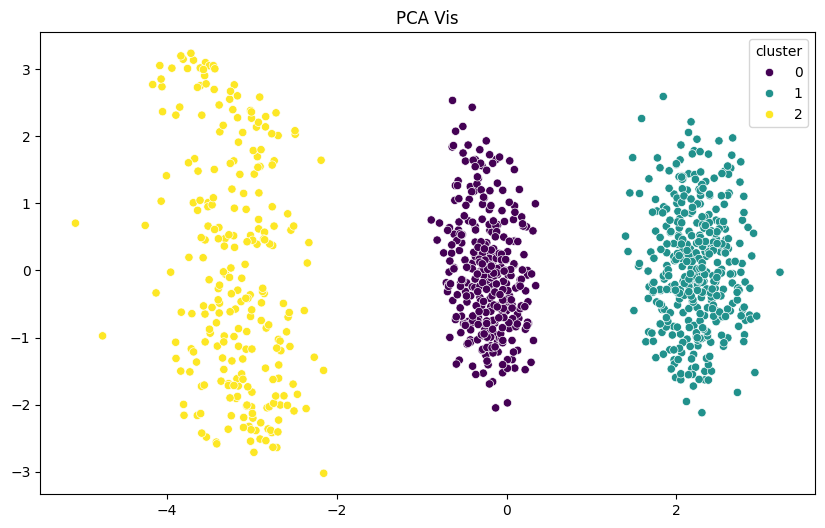

In [22]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_features)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=final_df['cluster'], palette='viridis')
plt.title('PCA Vis')
plt.show()

In [25]:
centroids = loaded_model.cluster_centers_
print(centroids)

[[-0.51228971 -0.05556464 -0.11645193 -0.32461395  0.70247508  0.00866491
  -0.11292682 -0.02971817  0.00557214 -0.03548119  0.03051819  0.0176192
   0.01349619 -0.03968676  0.00159413  0.04009211 -0.03271121 -0.03143514
   0.01865963  0.04676304 -0.02351201]
 [ 1.19963756  1.00256038  1.05411646  1.13047943  0.26338327 -0.54074654
  -0.1701641  -0.04979135  0.04415168 -0.04664753 -0.02446191 -0.0069547
   0.05290622 -0.00420327  0.04064499 -0.02935957  0.06499323 -0.01870241
   0.01570308 -0.01813823 -0.04596977]
 [-1.13874908 -1.49550059 -1.48770089 -1.30393842 -1.43957844  0.83771958
   0.4324335   0.12167986 -0.0775656   0.12514809 -0.00607838 -0.01478152
  -0.10289938  0.06453986 -0.06624443 -0.01235125 -0.05445929  0.07529621
  -0.0519314  -0.03973512  0.10661112]]


In [27]:
final_df[["cluster", "style"]]

,cluster,style
0,1,short_term
1,1,short_term
2,0,swing
3,0,swing
4,0,swing
...,...,...
995,0,swing
996,2,long_term
997,1,short_term
998,0,swing


In [29]:
BASE_URL = "http://localhost:8080/api/v1"

for customer_id in customer_ids:
    res = requests.post(
        f"{BASE_URL}/user/behaviour/create",
        json={
            "customer_id": customer_id,
            "behaviour_data": behaviour_data[customer_id]
        }
    )